In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
from torch.utils.data import DataLoader, Dataset
from pathlib import Path
from PIL import Image

class OxfordDataset(Dataset):
    def __init__(self, images_dir: Path, labels_dir: Path, transform=None):
        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)
        self.transform = transform

        allowed_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        self.samples = []

        for image_path in self.images_dir.iterdir():
            if image_path.suffix.lower() not in allowed_ext:
                continue

            label_path = self.labels_dir / f"{image_path.stem}.txt"
            if label_path.exists():
                self.samples.append((image_path, label_path))

        if not self.samples:
            raise RuntimeError(f"Nu exista perechi imagine-label in {self.images_dir}")

    def __len__(self):
        return len(self.samples)

    def _read_label(self, label_path: Path, imageWidth, imageHeight):
        boxes = None
        with open(label_path, 'r') as f:
            boxes = [line.strip() for line in f.readlines()]

        boundingBoxes = []
        for box in boxes:
            features = box.split(" ")
            cls = int(features[0])
            xmin, ymin, xmax, ymax = [float(point) for point in features[1:]]
            boundingBoxes.append([cls,
                                xmin / imageWidth,
                                ymin / imageHeight,
                                xmax / imageWidth,
                                ymax / imageHeight])

        if not boundingBoxes:
            return torch.zeros((0, 5), dtype=torch.float32)
        
        return torch.tensor(boundingBoxes, dtype=torch.float32)

    def __getitem__(self, idx):
        image_path, label_path = self.samples[idx]

        image = Image.open(image_path).convert("RGB")

        orig_w, orig_h = image.size

        if self.transform is not None:
            image = self.transform(image)

        label = self._read_label(label_path, orig_w, orig_h)
        return image, label


In [ ]:
from torchvision import transforms

image_size = 300

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
])

trainDataset = OxfordDataset("dataset/oxford_hands/training_dataset/training_data/images",
                        "dataset/oxford_hands/training_dataset/training_data/annotations/converted",
                        transform=transform)
                        
testDataset = OxfordDataset("dataset/oxford_hands/test_dataset/test_data/images",
                        "dataset/oxford_hands/test_dataset/test_data/annotations/converted",
                        transform=transform)

tensor([[1.0000, 0.2385, 0.6560, 0.3062, 0.7410],
        [1.0000, 0.5755, 0.7574, 0.6346, 0.8226]])


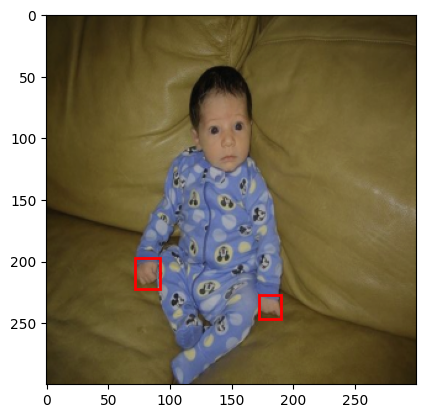

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img_tensor, label_tensor = testDataset[1]
print(label_tensor)

img = img_tensor.permute(1, 2, 0).numpy() 

fig, ax = plt.subplots(1)
ax.imshow(img)

h, w, _ = img.shape

for box in label_tensor:
    cls, xmin, ymin, xmax, ymax = box
    rect = patches.Rectangle(
        (xmin * w, ymin * h), 
        (xmax - xmin) * w, 
        (ymax - ymin) * h, 
        linewidth=2, edgecolor='r', facecolor='none'
    )
    ax.add_patch(rect)

plt.show()

In [ ]:

from itertools import product
from math import sqrt

class AnchorGenerator:
    def __init__(self, image_size=300):
        self.image_size = image_size
        
        self.feature_maps = [38, 19, 10, 5, 3, 1]
        self.min_sizes = [30, 60, 111, 162, 213, 264]
        self.max_sizes = [60, 111, 162, 213, 264, 315]

        self.aspect_ratios = [[2, 3]] * len(self.feature_maps)

    def generate(self):
        anchors = []
        for k, f in enumerate(self.feature_maps):
            for i, j in product(range(f), repeat=2):
                cx = (j + 0.5) / f
                cy = (i + 0.5) / f

                s_k = self.min_sizes[k] / self.image_size
                s_k_prime = sqrt(s_k * (self.max_sizes[k] / self.image_size))
                anchors.append([cx, cy, s_k, s_k])
                anchors.append([cx, cy, s_k_prime, s_k_prime])

                for ar in self.aspect_ratios[k]:
                    anchors.append([cx, cy, s_k * sqrt(ar), s_k / sqrt(ar)]) 
                    anchors.append([cx, cy, s_k / sqrt(ar), s_k * sqrt(ar)]) 

        
        output = torch.tensor(anchors).view(-1, 4)

        output.clamp_(max=1, min=0) 
        
        return output
  

anchor_gen = AnchorGenerator(image_size=300)
default_boxes = anchor_gen.generate()

In [ ]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

batchSize = 32

def collate_fn(batch):
    return tuple(zip(*batch))

trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True, collate_fn=collate_fn)
testLoader = DataLoader(testDataset, batch_size=batchSize, shuffle=False, collate_fn= collate_fn)

def evaluate_model(net: nn.Module, test_loader: DataLoader, loss_fn: nn.Module):
    net.eval() 
    total_loss = 0.0
    batches = 0

    with torch.no_grad():
        for test_images, test_labels in test_loader:

            test_images = torch.stack(test_images).to(device)

            test_labels = [l.to(device) for l in test_labels]

            out = net(test_images)
            loss = loss_fn(out, test_labels)
            total_loss += loss.item()
            batches += 1

    
    return total_loss / batches if batches > 0 else 0


def train_fn(epochs: int, train_loader: DataLoader, test_loader: DataLoader,
             net: nn.Module, loss_fn: nn.Module, optimizer: optim.Optimizer):
    bestValLoss = float('inf')

    for e in range(epochs):
        net.train() 
        train_loss_acumulat = 0.0

        for images, labels in train_loader:
            
            images = torch.stack(images).to(device)
            labels = [l.to(device) for l in labels]

            optimizer.zero_grad() 
            out = net(images)
            loss = loss_fn(out, labels)
            loss.backward()
            optimizer.step()

            train_loss_acumulat += loss.item()

        
        avg_train_loss = train_loss_acumulat / len(train_loader)
        val_loss = evaluate_model(net, test_loader, loss_fn)

        if val_loss < bestValLoss:
            bestValLoss = val_loss
            torch.save(net.state_dict(), 'best_model.pth')

        print(f"Epoca {e + 1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Validation Loss: {val_loss:.4f}")



In [10]:
from model2 import HandDetectionNetwork, HandTrackerLoss

net = HandDetectionNetwork(6)
net.load_state_dict(torch.load("best_model1.pth", weights_only = True))
net.to(device)

optimizer = optim.Adam(net.parameters(), lr=0.00005, weight_decay=1e-4)

loss_fn = HandTrackerLoss(anchors_cxcy=default_boxes)


In [11]:

print("Incepem antrenamentul...")
train_fn(epochs=100, 
            train_loader=trainLoader, 
            test_loader=testLoader, 
            net=net, 
            loss_fn=loss_fn, 
            optimizer=optimizer)

Incepem antrenamentul...
Epoca 1/100 | Train Loss: 7.4636 | Validation Loss: 9.0956
Epoca 2/100 | Train Loss: 7.0655 | Validation Loss: 9.1186
Epoca 3/100 | Train Loss: 6.9281 | Validation Loss: 9.1587
Epoca 4/100 | Train Loss: 6.8265 | Validation Loss: 9.1577


KeyboardInterrupt: 